In [1]:
# DEFINING AUC AND ROC WITH INBUILT FUNCTIONS


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
df = pd.read_csv("/content/telescope_data.csv.zip")
df

,Unnamed: 0,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g
...,...,...,...,...,...,...,...,...,...,...,...,...
19015,19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19016,19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19017,19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19018,19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h


In [8]:
df = df.drop(columns=["Unnamed: 0"])
df["class"] = df["class"].map({"g": 1, "h": 0})
X = df[["fLength"]].values
y = df["class"].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [15]:
y_prob = model.predict_proba(X_test)[:, 1]

In [16]:
# calculation auc and roc
from sklearn.metrics import roc_curve, roc_auc_score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

AUC Score: 0.6178530562346449


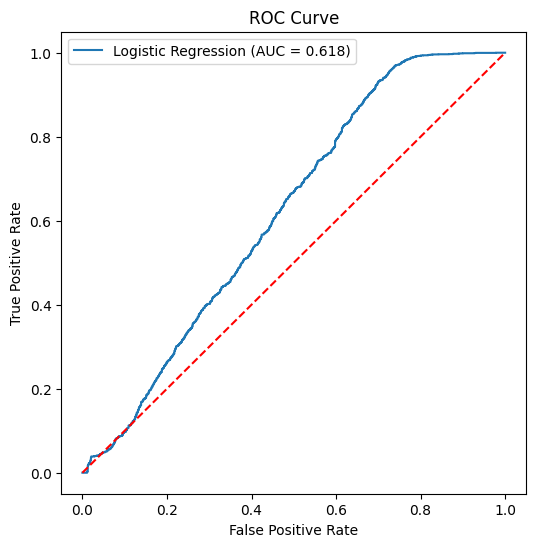

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Logistic Regression (AUC = %0.3f)" % auc_score)
plt.plot([0,1], [0,1], linestyle='--', color='red')  # Random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

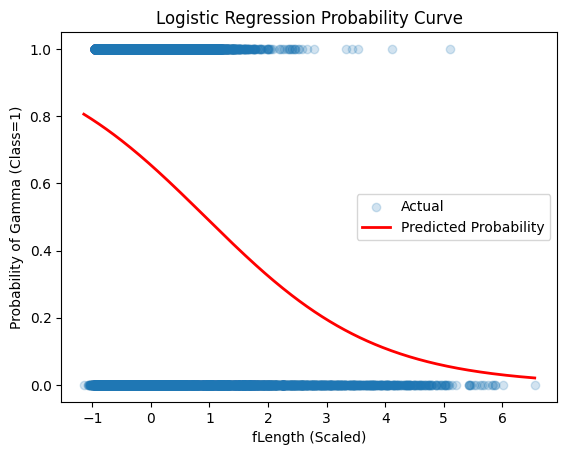

In [10]:
X_range = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1,1)
y_prob = model.predict_proba(X_range)[:,1]
plt.scatter(X_train, y_train, alpha=0.2, label="Actual")
plt.plot(X_range, y_prob, color="red", linewidth=2, label="Predicted Probability")
plt.xlabel("fLength (Scaled)")
plt.ylabel("Probability of Gamma (Class=1)")
plt.title("Logistic Regression Probability Curve")
plt.legend()
plt.show()



In [11]:
value = float(input("Enter fLength value: "))
user_input = np.array([[value]])
user_input_scaled = scaler.transform(user_input)
prediction = model.predict(user_input_scaled)
probability = model.predict_proba(user_input_scaled)

if prediction[0] == 1:
    print("Prediction: Gamma (g)")
else:
    print("Prediction: Hadron (h)")


Enter fLength value: 28.9879
Prediction: Gamma (g)


In [18]:
# calculating auc roc without inbuilt function

Manual AUC: 0.6178403657987981


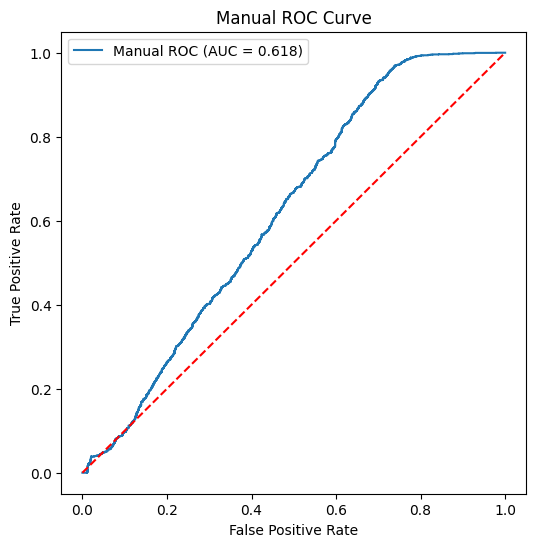

In [19]:
import numpy as np
y_test = np.array(y_test)
y_prob = np.array(y_prob)
# creating thresholds
thresholds = np.sort(np.unique(y_prob))[::-1]
# calculating tpr and fpr
tpr_list = []
fpr_list = []

P = np.sum(y_test == 1)
N = np.sum(y_test == 0)

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    TP = np.sum((y_pred == 1) & (y_test == 1))
    FP = np.sum((y_pred == 1) & (y_test == 0))

    TPR = TP / P
    FPR = FP / N

    tpr_list.append(TPR)
    fpr_list.append(FPR)
tpr_list = np.array([0] + tpr_list + [1])
fpr_list = np.array([0] + fpr_list + [1])
# sort by fpr important for auc
sorted_indices = np.argsort(fpr_list)
fpr_list = fpr_list[sorted_indices]
tpr_list = tpr_list[sorted_indices]
# calculating auc
auc = 0

for i in range(1, len(fpr_list)):
    auc += (fpr_list[i] - fpr_list[i-1]) * (tpr_list[i] + tpr_list[i-1]) / 2

print("Manual AUC:", auc)

# ploting
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(fpr_list, tpr_list, label=f"Manual ROC (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='red')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual ROC Curve")
plt.legend()
plt.show()